# 09 · Honest validation and model selection

**ROBT613 · Brain–Computer Interfaces** | 90–120 min

## Goal
Compare classifiers with nested run-grouped validation, distinguish uncertainty units and diagnose leakage.

**Data:** EEGBCI subject 1, three independent run groups

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

A test score estimates performance on the distribution represented by the held-out unit. Holding out trials, runs, sessions and people answers different questions. If adjacent windows share EEG samples, random window splitting can make generalization look much stronger than it is.

Nested cross-validation separates model selection from evaluation: for each outer split, choose hyperparameters using only inner folds of the outer training set, refit, then score the outer test set once. For balanced accuracy $BA=K^{-1}\sum_k TP_k/(TP_k+FN_k)$. A confusion matrix reveals which classes contribute to a mean score.

A bootstrap must resample independent units. Thousands of correlated epochs from one participant do not provide thousands of independent estimates of population performance. Three run scores are too few for a precise uncertainty estimate. Permutation tests must respect exchangeability (e.g. experimental blocks); shuffling arbitrary overlapping flash labels is not automatically valid.

## Load an auditable benchmark
This lesson deliberately keeps all three run IDs.

In [2]:
from mne.datasets import eegbci
runs = [4, 8, 12]  # ALL are imagined left versus right fist, not hands versus feet
parts, groups = [], []
for run in runs:
    paths = eegbci.load_data(1, [run], path=DATA_ROOT, update_path=False)
    raw_run = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
    eegbci.standardize(raw_run)
    raw_run.set_montage('standard_1005')
    raw_run.set_eeg_reference('average', projection=False)
    raw_run.filter(8, 30, fir_design='firwin')
    events, _ = mne.events_from_annotations(raw_run, event_id={'T1': 1, 'T2': 2})
    ep = mne.Epochs(raw_run, events, {'left': 1, 'right': 2}, tmin=0.5,
                    tmax=3.5, baseline=None, preload=True, picks='eeg',
                    reject_by_annotation=True)
    parts.append(ep)
    groups.extend([run] * len(ep))
epochs = mne.concatenate_epochs(parts)
X = epochs.get_data(copy=True)
y = epochs.events[:, 2] - 1
groups = np.asarray(groups)
print('Epochs:', X.shape, 'run counts:', pd.Series(groups).value_counts().to_dict())

/tmp/ipykernel_418571/2492561078.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


/tmp/ipykernel_418571/2492561078.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


Epochs: (45, 64, 481) run counts: {4: 15, 8: 15, 12: 15}


/tmp/ipykernel_418571/2492561078.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')
/tmp/ipykernel_418571/2492561078.py:17: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(parts)


## Nested model comparison
With three runs, each outer training fold contains two runs, so the inner loop uses two groups. All learned transformations remain inside the pipeline.

   held_out_run  balanced_accuracy  components
0            12           0.616071           2
1             8           0.660714           4
2             4           0.562500           4


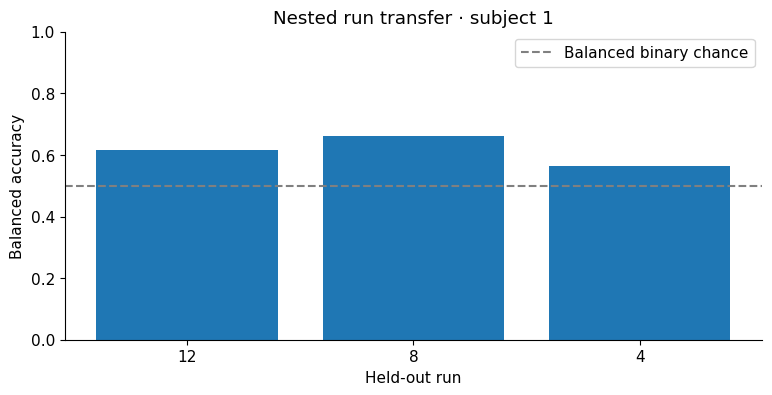

In [3]:
from mne.decoding import CSP
outer=GroupKFold(3)
rows=[]
for fold,(tr,te) in enumerate(outer.split(X,y,groups),1):
    model=make_pipeline(CSP(n_components=4,reg='ledoit_wolf',log=True),
                        LinearDiscriminantAnalysis(solver='lsqr',shrinkage='auto'))
    search=GridSearchCV(model,{'csp__n_components':[2,4]},cv=GroupKFold(2),
                        scoring='balanced_accuracy',n_jobs=1)
    search.fit(X[tr],y[tr],groups=groups[tr])
    score=balanced_accuracy_score(y[te],search.predict(X[te]))
    rows.append({'held_out_run':int(groups[te][0]),'balanced_accuracy':score,
                 'components':search.best_params_['csp__n_components']})
results=pd.DataFrame(rows)
print(results)
fig,ax=plt.subplots()
ax.bar(results.held_out_run.astype(str),results.balanced_accuracy)
ax.axhline(.5,color='gray',linestyle='--',label='Balanced binary chance')
ax.set(ylim=(0,1),xlabel='Held-out run',ylabel='Balanced accuracy',title='Nested run transfer · subject 1')
ax.legend(); plt.show()

## Exercises and checks
1. Write down the split unit before running an experiment.
2. Intentionally compare random trial splits as a labeled sensitivity analysis, not as the preferred estimate.
3. Plan a leave-one-subject-out design and identify where normalization must be fitted.
4. Explain why repeatedly inspecting a held-out score turns that set into validation data.
5. Add a dummy classifier and report its score next to CSP.

## Next steps and sources
[Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) · [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.